In [ ]:
# TP1 — Semana 04
# Baseline de Projeto de Pesquisa
# RSNA Pediatric Bone Age

import os
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("Ambiente configurado.")
print("SEED:", SEED)

Ambiente configurado.
SEED: 42


In [ ]:
!pip install -q kagglehub

import kagglehub

dataset_path = kagglehub.dataset_download("kmader/rsna-bone-age")

print("Dataset disponível em:")
print(dataset_path)

100%|██████████| 9.29G/9.29G [08:11<00:00, 20.3MB/s]

Extracting files...


Dataset disponível em:
/root/.cache/kagglehub/datasets/kmader/rsna-bone-age/versions/2


In [ ]:
# Localização dos arquivos do dataset

BASE_DIR = dataset_path

TRAIN_CSV = os.path.join(
    BASE_DIR,
    "boneage-training-dataset.csv"
)

TRAIN_IMG_DIR = os.path.join(
    BASE_DIR,
    "boneage-training-dataset"
)

df = pd.read_csv(TRAIN_CSV)

print("Dataset carregado!")
print("Quantidade de exames:", len(df))
print("Colunas:", list(df.columns))

Dataset carregado!
Quantidade de exames: 12611
Colunas: ['id', 'boneage', 'male']


In [ ]:
from sklearn.model_selection import train_test_split

df_treino, df_validacao = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED
)

print("Treino:", len(df_treino))
print("Validação:", len(df_validacao))

Treino: 10088
Validação: 2523


In [ ]:
df_treino_amostra = df_treino.sample(
    n=3000,
    random_state=SEED
).copy()

df_validacao_amostra = df_validacao.sample(
    n=750,
    random_state=SEED
).copy()

print("Amostra de treino:", df_treino_amostra.shape)
print("Amostra de validação:", df_validacao_amostra.shape)

Amostra de treino: (3000, 3)
Amostra de validação: (750, 3)


In [ ]:
from PIL import Image
from skimage.feature import hog

TAMANHO = (256, 256)

def extrair_hog_compacto(imagem_id):
    caminho_imagem = os.path.join(
        TRAIN_IMG_DIR,
        "boneage-training-dataset",
        f"{int(imagem_id)}.png"
    )

    imagem = Image.open(caminho_imagem).convert("L")
    imagem = imagem.resize(TAMANHO)

    imagem_array = np.array(imagem)
    imagem_normalizada = imagem_array.astype(np.float32) / 255.0

    caracteristicas = hog(
        imagem_normalizada,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )

    return caracteristicas.astype(np.float32)

print("Função HOG definida.")

Função HOG definida.


In [ ]:
inicio = time.time()

X_treino_hog = np.array([
    extrair_hog_compacto(imagem_id)
    for imagem_id in df_treino_amostra["id"]
])

tempo = time.time() - inicio

print("HOG de treino extraído.")
print("Formato:", X_treino_hog.shape)
print(f"Tempo total: {tempo/60:.2f} minutos")

HOG de treino extraído.
Formato: (3000, 8100)
Tempo total: 3.07 minutos


In [ ]:
inicio = time.time()

X_validacao_hog = np.array([
    extrair_hog_compacto(imagem_id)
    for imagem_id in df_validacao_amostra["id"]
])

tempo = time.time() - inicio

print("HOG de validação extraído.")
print("Formato:", X_validacao_hog.shape)
print(f"Tempo total: {tempo/60:.2f} minutos")

HOG de validação extraído.
Formato: (750, 8100)
Tempo total: 0.96 minutos


In [ ]:
# Adicionando sexo como covariável

sexo_treino = df_treino_amostra["male"].astype(np.float32).values.reshape(-1, 1)
sexo_validacao = df_validacao_amostra["male"].astype(np.float32).values.reshape(-1, 1)

X_treino_hog_sexo = np.hstack([
    X_treino_hog,
    sexo_treino
])

X_validacao_hog_sexo = np.hstack([
    X_validacao_hog,
    sexo_validacao
])

y_treino = df_treino_amostra["boneage"].values.astype(np.float32)
y_validacao = df_validacao_amostra["boneage"].values.astype(np.float32)

print("Características preparadas.")
print("Treino:", X_treino_hog_sexo.shape)
print("Validação:", X_validacao_hog_sexo.shape)
print("y treino:", y_treino.shape)
print("y validação:", y_validacao.shape)

Características preparadas.
Treino: (3000, 8101)
Validação: (750, 8101)
y treino: (3000,)
y validação: (750,)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

modelo_final = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=100.0))
])

inicio = time.time()

modelo_final.fit(X_treino_hog_sexo, y_treino)

tempo = time.time() - inicio

print("Modelo final treinado.")
print(f"Tempo de treinamento: {tempo:.2f} segundos")

Modelo final treinado.
Tempo de treinamento: 6.23 segundos


In [ ]:
previsoes_finais = modelo_final.predict(X_validacao_hog_sexo)

print("Previsões realizadas.")
print("Quantidade de previsões:", len(previsoes_finais))
print("Primeiras previsões:")
print(previsoes_finais[:10])

Previsões realizadas.
Quantidade de previsões: 750
Primeiras previsões:
[114.7327    43.91764  148.65845  177.34834  188.4211   127.87055
 133.32997  182.83109   98.088715 110.659935]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_final = mean_absolute_error(y_validacao, previsoes_finais)
rmse_final = np.sqrt(mean_squared_error(y_validacao, previsoes_finais))
r2_final = r2_score(y_validacao, previsoes_finais)

print("=== MÉTRICAS FINAIS ===")
print(f"MAE:  {mae_final:.2f} meses")
print(f"RMSE: {rmse_final:.2f} meses")
print(f"R²:   {r2_final:.4f}")

=== MÉTRICAS FINAIS ===
MAE:  25.52 meses
RMSE: 34.20 meses
R²:   0.3067


In [ ]:
resultados = df_validacao_amostra[["id", "boneage", "male"]].copy()

resultados["idade_prevista"] = previsoes_finais
resultados["erro"] = resultados["idade_prevista"] - resultados["boneage"]
resultados["erro_absoluto"] = np.abs(resultados["erro"])

resultados.head(10)

,id,boneage,male,idade_prevista,erro,erro_absoluto
11768,14675,132,True,114.732697,-17.267303,17.267303
7539,9936,60,False,43.917641,-16.082359,16.082359
4991,7106,120,False,148.658447,28.658447,28.658447
7238,9597,186,True,177.348343,-8.651657,8.651657
5272,7420,138,True,188.421097,50.421097,50.421097
469,1906,120,False,127.870552,7.870552,7.870552
9804,12482,90,True,133.329971,43.329971,43.329971
7814,10244,162,True,182.831085,20.831085,20.831085
10198,12916,144,False,98.088715,-45.911285,45.911285
7707,10120,138,True,110.659935,-27.340065,27.340065


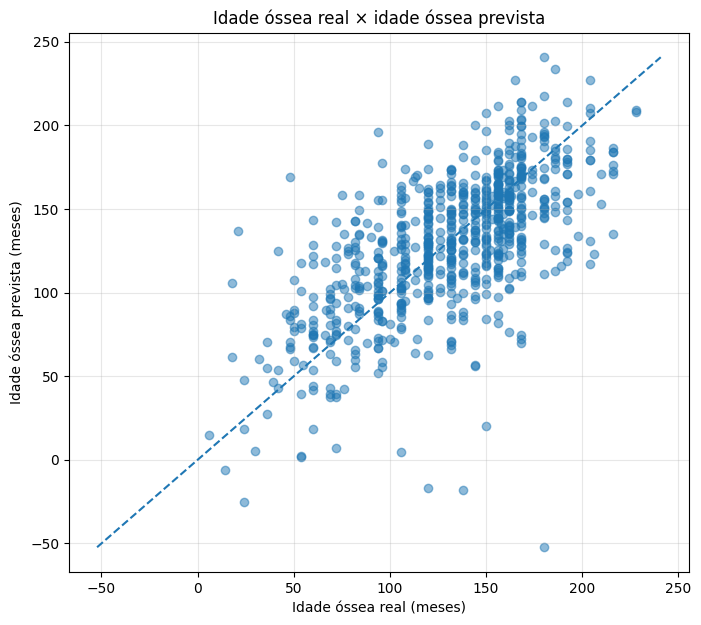

In [ ]:
plt.figure(figsize=(8, 7))

plt.scatter(
    resultados["boneage"],
    resultados["idade_prevista"],
    alpha=0.5
)

# Linha de previsão perfeita
limite_min = min(
    resultados["boneage"].min(),
    resultados["idade_prevista"].min()
)

limite_max = max(
    resultados["boneage"].max(),
    resultados["idade_prevista"].max()
)

plt.plot(
    [limite_min, limite_max],
    [limite_min, limite_max],
    linestyle="--"
)

plt.xlabel("Idade óssea real (meses)")
plt.ylabel("Idade óssea prevista (meses)")
plt.title("Idade óssea real × idade óssea prevista")
plt.grid(alpha=0.3)

plt.show()

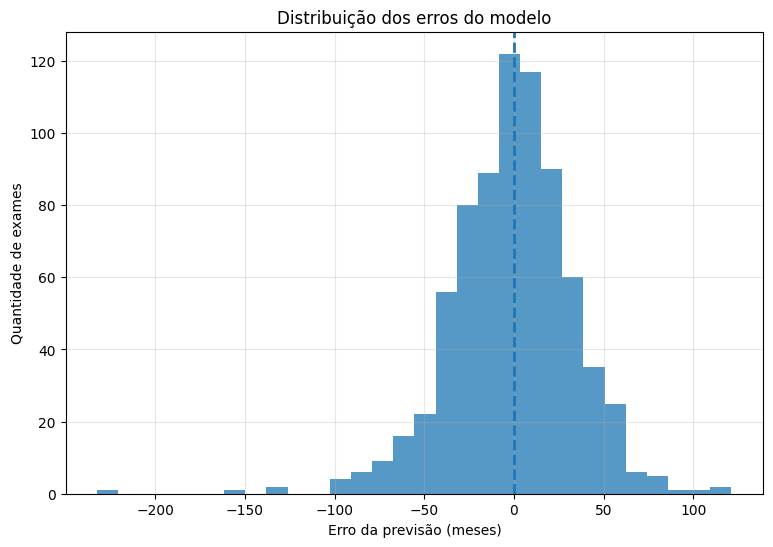

In [ ]:
plt.figure(figsize=(9, 6))

plt.hist(
    resultados["erro"],
    bins=30,
    alpha=0.75
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Erro da previsão (meses)")
plt.ylabel("Quantidade de exames")
plt.title("Distribuição dos erros do modelo")
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# Definição das faixas etárias
bins = [0, 60, 120, 180, 228]
labels = [
    "0–60 meses",
    "61–120 meses",
    "121–180 meses",
    "181–228 meses"
]

resultados["faixa_etaria"] = pd.cut(
    resultados["boneage"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Cálculo das métricas por faixa
analise_faixas = (
    resultados
    .groupby("faixa_etaria", observed=False)
    .apply(
        lambda grupo: pd.Series({
            "N": len(grupo),
            "MAE": np.mean(np.abs(grupo["erro"])),
            "RMSE": np.sqrt(np.mean(grupo["erro"] ** 2)),
            "Erro médio": np.mean(grupo["erro"])
        }),
        include_groups=False
    )
)

analise_faixas

,N,MAE,RMSE,Erro médio
faixa_etaria,,,,
0–60 meses,57.0,33.518155,42.719636,22.668658
61–120 meses,247.0,25.136480,32.500286,11.739272
121–180 meses,390.0,23.273034,32.548739,-8.295744
181–228 meses,56.0,34.669790,42.111981,-30.142148


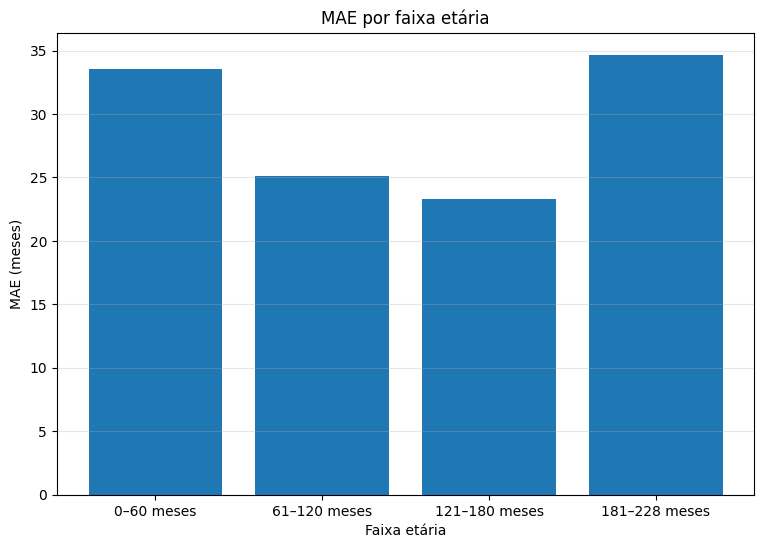

In [ ]:
plt.figure(figsize=(9, 6))

plt.bar(
    analise_faixas.index.astype(str),
    analise_faixas["MAE"]
)

plt.xlabel("Faixa etária")
plt.ylabel("MAE (meses)")
plt.title("MAE por faixa etária")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [ ]:
maiores_erros = (
    resultados
    .sort_values("erro_absoluto", ascending=False)
    [["id", "boneage", "idade_prevista", "erro", "erro_absoluto", "male"]]
    .head(10)
)

maiores_erros


,id,boneage,idade_prevista,erro,erro_absoluto,male
1323,2848,180,-52.282875,-232.282875,232.282875,True
303,1714,138,-17.989082,-155.989082,155.989082,True
6306,8566,120,-17.066750,-137.066750,137.066750,False
6443,8724,150,20.352051,-129.647949,129.647949,True
102,1491,48,169.292542,121.292542,121.292542,True
6425,8706,21,136.638550,115.638550,115.638550,False
10202,12920,94,196.206055,102.206055,102.206055,True
9763,12437,106,4.680901,-101.319099,101.319099,False
6486,8773,168,70.103043,-97.896957,97.896957,True
4687,6769,168,72.568039,-95.431961,95.431961,True


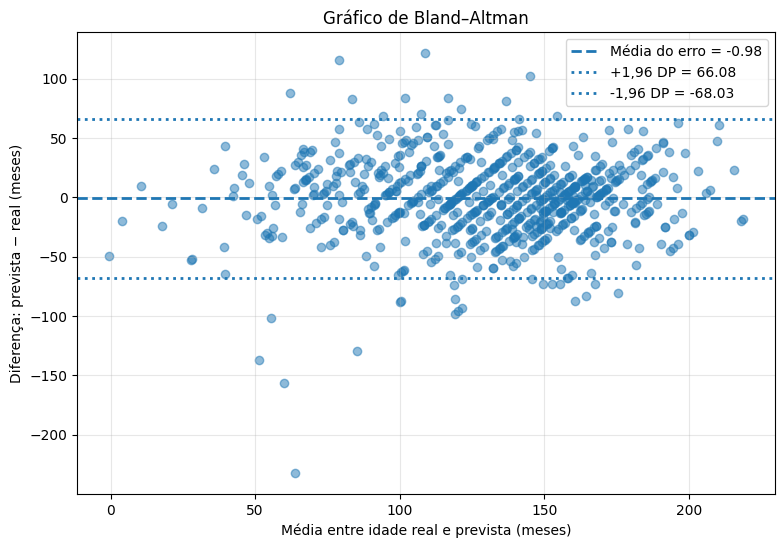

=== Bland–Altman ===
Média do erro: -0.98 meses
Desvio padrão do erro: 34.21 meses
Limite superior: 66.08 meses
Limite inferior: -68.03 meses


In [ ]:
# Cálculo dos valores para o gráfico de Bland-Altman

idade_real = resultados["boneage"].values
idade_prevista = resultados["idade_prevista"].values

media_idades = (idade_real + idade_prevista) / 2
diferencas = idade_prevista - idade_real

media_erro = np.mean(diferencas)
desvio_erro = np.std(diferencas, ddof=1)

limite_superior = media_erro + 1.96 * desvio_erro
limite_inferior = media_erro - 1.96 * desvio_erro

plt.figure(figsize=(9, 6))

plt.scatter(
    media_idades,
    diferencas,
    alpha=0.5
)

plt.axhline(
    media_erro,
    linestyle="--",
    linewidth=2,
    label=f"Média do erro = {media_erro:.2f}"
)

plt.axhline(
    limite_superior,
    linestyle=":",
    linewidth=2,
    label=f"+1,96 DP = {limite_superior:.2f}"
)

plt.axhline(
    limite_inferior,
    linestyle=":",
    linewidth=2,
    label=f"-1,96 DP = {limite_inferior:.2f}"
)

plt.xlabel("Média entre idade real e prevista (meses)")
plt.ylabel("Diferença: prevista − real (meses)")
plt.title("Gráfico de Bland–Altman")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

print("=== Bland–Altman ===")
print(f"Média do erro: {media_erro:.2f} meses")
print(f"Desvio padrão do erro: {desvio_erro:.2f} meses")
print(f"Limite superior: {limite_superior:.2f} meses")
print(f"Limite inferior: {limite_inferior:.2f} meses")

In [ ]:
limites_erro = [12, 24, 36]

print("=== DISTRIBUIÇÃO DOS ERROS ABSOLUTOS ===")

for limite in limites_erro:
    quantidade = (resultados["erro_absoluto"] <= limite).sum()
    percentual = quantidade / len(resultados) * 100

    print(
        f"Erro absoluto ≤ {limite} meses: "
        f"{quantidade} exames ({percentual:.2f}%)"
    )

=== DISTRIBUIÇÃO DOS ERROS ABSOLUTOS ===
Erro absoluto ≤ 12 meses: 234 exames (31.20%)
Erro absoluto ≤ 24 meses: 426 exames (56.80%)
Erro absoluto ≤ 36 meses: 570 exames (76.00%)


In [ ]:
resultados_modelos = pd.DataFrame({
    "Modelo": [
        "Baseline - Média",
        "Ridge + HOG",
        "Random Forest + HOG",
        "Decision Tree + HOG",
        "Ridge + HOG + sexo"
    ],
    "MAE (meses)": [
        34.51,
        26.74,
        28.62,
        31.84,
        25.52
    ],
    "RMSE (meses)": [
        42.09,
        35.81,
        34.94,
        40.37,
        34.20
    ],
    "R²": [
        -0.0002,
        0.2400,
        0.2767,
        0.0341,
        0.3067
    ]
})

resultados_modelos

,Modelo,MAE (meses),RMSE (meses),R²
0,Baseline - Média,34.51,42.09,-0.0002
1,Ridge + HOG,26.74,35.81,0.2400
2,Random Forest + HOG,28.62,34.94,0.2767
3,Decision Tree + HOG,31.84,40.37,0.0341
4,Ridge + HOG + sexo,25.52,34.20,0.3067


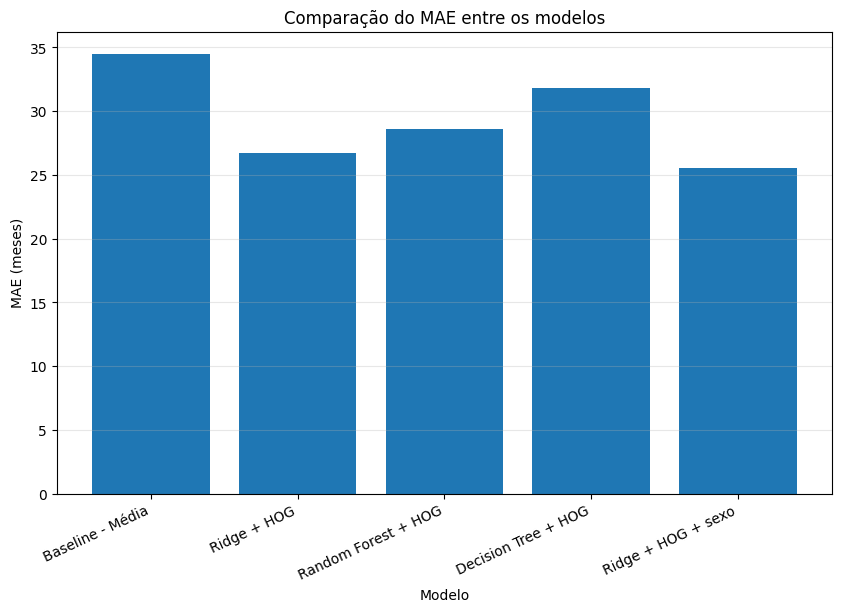

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    resultados_modelos["Modelo"],
    resultados_modelos["MAE (meses)"]
)

plt.ylabel("MAE (meses)")
plt.xlabel("Modelo")
plt.title("Comparação do MAE entre os modelos")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.show()